<h2 align="center">Лабораторна робота № 6<br>Варіант 7</h2>

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def exact_solution(x):
    return x * np.tan(x)

In [23]:
def f(x, y):
    F_x = np.tan(x) + x * (1/np.cos(x))**2 + x * exact_solution(x)
    return -x * y + F_x

In [ ]:
# Метод Рунге-Кутта 4-го порядку
def RK4_step(xi, yi, h, func):
    k1 = h * func(xi, yi)
    k2 = h * func(xi + h/2, yi + k1/2)
    k3 = h * func(xi + h/2, yi + k2/2)
    k4 = h * func(xi + h, yi + k3)
    return yi + (k1 + 2*k2 + 2*k3 + k4) / 6

In [25]:
# Розв'язання методом Рунге-Кутта на всьому відрізку
def solve_RK4(x0, y0, X, h, func):
    x_vals = np.arange(x0, X + h/2, h) 
    y_vals = np.zeros_like(x_vals)
    y_vals[0] = y0
    for i in range(1, len(x_vals)):
        y_vals[i] = RK4_step(x_vals[i-1], y_vals[i-1], h, func)
    return x_vals, y_vals

In [26]:
# Метод Адамса-Башфорта 4-го порядку (екстраполяційний)
def AB4_step(x, y, i, h, func):
    # Використовуємо 4 попередні точки: i-1, i-2, i-3, i-4
    f0 = func(x[i-1], y[i-1])
    f1 = func(x[i-2], y[i-2])
    f2 = func(x[i-3], y[i-3])
    f3 = func(x[i-4], y[i-4])
    return y[i-1] + (h / 24) * (55*f0 - 59*f1 + 37*f2 - 9*f3)

In [27]:
# Початкові умови та параметри сітки
x0 = 0.0
y0 = 0.0
X_end = 1.0
h = 0.1

In [28]:
print("Theoretical errors:")
print(f"RK4 error ~ O(h^4) = {h**4:.2e}")
print(f"AB4 error ~ O(h^4) = {h**4:.2e}\n")

# 1. Знаходимо розв'язок методом Рунге-Кутта
x_vals, y_rk4 = solve_RK4(x0, y0, X_end, h, f)

# 2. Знаходимо розв'язок методом Адамса
y_ab4 = np.zeros_like(x_vals)
# Метод Адамса є багатокроковим, тому потребує 4 стартові точки. 
# Беремо перші 4 точки з більш точного Рунге-Кутта:
y_ab4[:4] = y_rk4[:4] 

for i in range(4, len(x_vals)):
    y_ab4[i] = AB4_step(x_vals, y_ab4, i, h, f)
    
# 3. Аналіз похибок
y_exact = exact_solution(x_vals)
err_rk4 = np.abs(y_exact - y_rk4)
err_ab4 = np.abs(y_exact - y_ab4)

# Вивід таблиці результатів
print(f"{'X':>6} {'y_exact':>12} {'y_RK4':>12} {'y_AB4':>12} {'err_RK4':>12} {'err_AB4':>12}")
for xi, ye, yr, ya, er, ea in zip(x_vals, y_exact, y_rk4, y_ab4, err_rk4, err_ab4):
    print(f"{xi:6.2f} {ye:12.6f} {yr:12.6f} {ya:12.6f} {er:12.2e} {ea:12.2e}")

Theoretical errors:
RK4 error ~ O(h^4) = 1.00e-04
AB4 error ~ O(h^4) = 1.00e-04

     X      y_exact        y_RK4        y_AB4      err_RK4      err_AB4
  0.00     0.000000     0.000000     0.000000     0.00e+00     0.00e+00
  0.10     0.010033     0.010034     0.010034     4.84e-08     4.84e-08
  0.20     0.040542     0.040542     0.040542     2.03e-07     2.03e-07
  0.30     0.092801     0.092801     0.092801     4.98e-07     4.98e-07
  0.40     0.169117     0.169118     0.169040     1.00e-06     7.75e-05
  0.50     0.273151     0.273153     0.272938     1.84e-06     2.13e-04
  0.60     0.410482     0.410485     0.410037     3.27e-06     4.45e-04
  0.70     0.589602     0.589608     0.588758     5.81e-06     8.44e-04
  0.80     0.823711     0.823721     0.822146     1.06e-05     1.56e-03
  0.90     1.134142     1.134163     1.131181     2.04e-05     2.96e-03
  1.00     1.557408     1.557450     1.551488     4.27e-05     5.92e-03


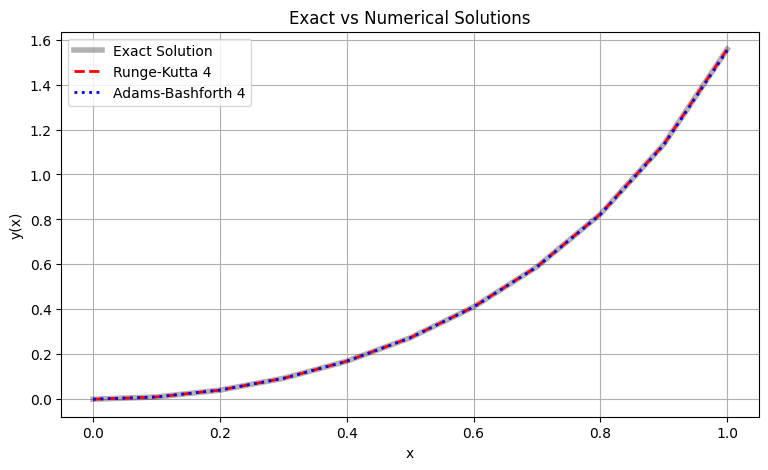

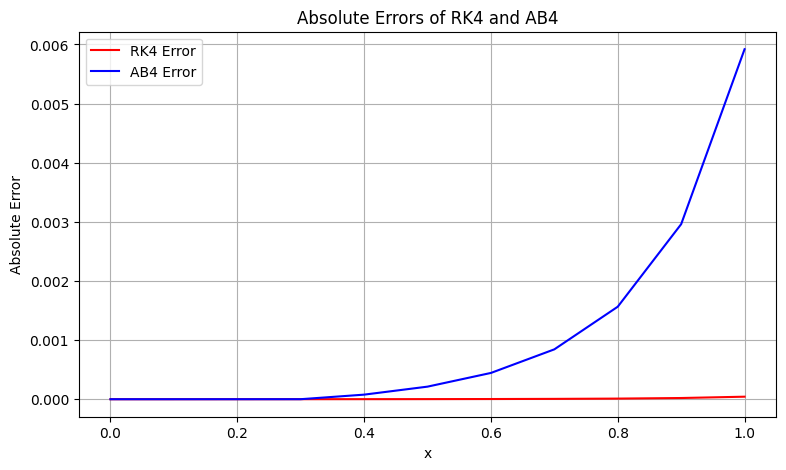

In [29]:
# Побудова графіків розв'язків
plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_exact, label='Exact Solution', lw=4, color='black', alpha=0.3)
plt.plot(x_vals, y_rk4, '--', label='Runge-Kutta 4', color='red', lw=2)
plt.plot(x_vals, y_ab4, ':', label='Adams-Bashforth 4', color='blue', lw=2)
plt.title("Exact vs Numerical Solutions")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True)
plt.show()

# Побудова графіків похибок
plt.figure(figsize=(9, 5))
plt.plot(x_vals, err_rk4, label='RK4 Error', color='red')
plt.plot(x_vals, err_ab4, label='AB4 Error', color='blue')
plt.title("Absolute Errors of RK4 and AB4")
plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True)
plt.show()